In [1]:
import numpy as np
import re
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [2]:
def load_glove_embeddings(glove_file):
    """Loads GloVe embeddings from a file."""
    embeddings = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
            
    return embeddings

In [3]:
def preprocess_text(text):
    # Maybe there's a better way to do this, but it gets hung up on reviews that are just integers 
    # I don't know why someone would leave such a review but there are a few
    text = str(text) 

    # Make lowercase and remove puncuation 
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    
    return word_tokenize(text)

In [4]:
def embed_text(sentence):
    tokens = preprocess_text(sentence)
    embedded_tokens = []
    for token in tokens:
        if token in stop_words:
            continue
            
        if token in glove_embeddings:
            embedded_tokens.append(glove_embeddings[token])
        
        else:
            # Handle out-of-vocabulary words (e.g., use a zero vector)
            embedded_tokens.append(np.zeros(glove_len))

    return np.array(embedded_tokens)

In [9]:
def embed_text_avg(sentence):
    embedded = embed_text(sentence)

    if len(embedded) == 0:
        return np.array([])
    
    return embedded.mean(axis=0)

In [11]:
## Get stopwords from nltk
stop_words = list(stopwords.words('english')) 

## Set directory of glove file and load the embeddings
glove_file = './glove-6B/glove.6B.100d.txt' 
glove_embeddings = load_glove_embeddings(glove_file)

## Set dim of GloVe vectors ('the' is the first entry in each model)
glove_len = len(glove_embeddings['the'])

#print(stop_words)

In [118]:
sentence = 'This restaurant sucked. They gave me food poisoning :('

good_words = [word for word in preprocess_text(sentence) if word not in stop_words]
embedded = embed_text(sentence)

print('setence length: ', len(sentence.split()))
print('embedded length: ', len(embedded))
print('Non stop-words: ', good_words)


setence length:  9
embedded length:  5
Non stop-words:  ['restaurant', 'sucked', 'gave', 'food', 'poisoning']


In [13]:
# Read CSV of sampled data
df = pd.read_csv('sampled.csv')

In [160]:
df['emb-100d'] = df['text'].apply(embed_text)
df['emb_avg-100d'] = df['text'].apply(embed_text_avg)    

In [17]:
df.count()

rating          60939
text            60939
type            60939
emb_avg-50d     60939
emb-50d         60939
emb-100d        60939
emb_avg-100d    60939
dtype: int64

In [ ]:
df.to_csv('sampled.csv', index=False)

In [154]:
def length_of_review(review):
    tokens = preprocess_text(review)
    
    return min(100, len(tokens))

df['length'] = df['text'].apply(length_of_review)

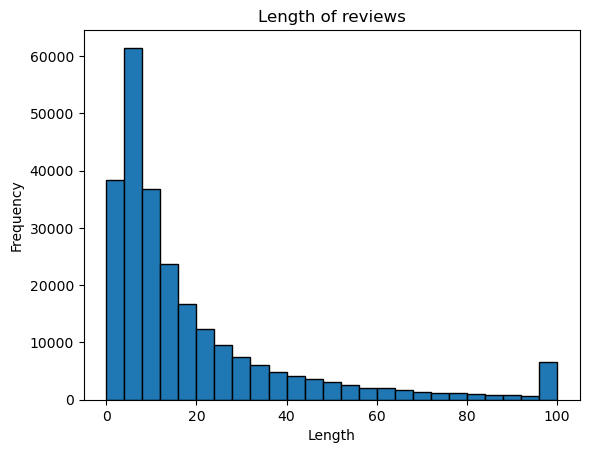

In [155]:
import matplotlib.pyplot as plt

# Plot histogram of the 'values' column
plt.hist(df['length'], bins=25, edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Length of reviews')

# Display the plot
plt.show()